# ProMuse - Review 1

## Prosody-Aware Emotion Recognition and Music Recommendation

ProMuse investigates personalized music recommendation from speech. This review establishes the speech-side foundation: acoustic/prosodic features, emotion recognition, and robustness to corpus shift. Robustness matters because a speech-emotion model can otherwise learn recording conditions, speakers, or corpus conventions rather than emotion.

DEAM is included as the downstream music resource because it provides continuous valence/arousal (V/A) annotations for songs. Review 1 ends primarily at the domain-adaptation and representation stage; it does **not** yet claim a finished recommender.

```text
Speech Input
     |
     v
Acoustic / Prosodic Features
     |
     v
Emotion Recognition
     |
     v
Domain Adaptation
     |
     v
Emotion Representation
     |
     +----------------------+
                            |
DEAM Music -> Valence/Arousal Space
                            |
                            v
                Music Recommendation
```

## 1. Imports and Reproducibility

All imports and experiment constants are defined once. `set_seed` covers Python, NumPy, PyTorch, CUDA (when available), and DataLoader generators as far as practical.

In [4]:
import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch import nn
from torch.autograd import Function
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

warnings.filterwarnings("ignore")

SEEDS = [42, 52, 62, 72, 82]
RANDOM_STATE = 42
TEST_SIZE = 0.20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed):
    """Set deterministic seeds for repeatable experiments where practical."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RANDOM_STATE)
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Project Paths

The root is located from the current working directory, so this notebook works when launched from either the project root or `notebooks/`. Required inputs are validated before analysis starts.

In [5]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data" / "metadata" / "speech_features.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not locate the ProMuse project root. Start the notebook from the "
        "project root or its notebooks directory; expected data/metadata/speech_features.csv."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
SPEECH_FILE = DATA_DIR / "metadata" / "speech_features.csv"
MUSIC_FILE = DATA_DIR / "processed" / "music_features.csv"
REVIEW_DIR = DATA_DIR / "processed" / "review_1"
FIGURE_DIR = REVIEW_DIR / "figures"
REVIEW_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for required_file in (SPEECH_FILE, MUSIC_FILE):
    if not required_file.is_file():
        raise FileNotFoundError(f"Required input is missing: {required_file}")

print("Project root:", PROJECT_ROOT)
print("Review outputs:", REVIEW_DIR)

Project root: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse
Review outputs: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1


## 3. Load Datasets

`speech_features.csv` is the authoritative speech-feature source throughout this notebook. The adapted speech file is deliberately not used as DANN input.

In [6]:
speech = pd.read_csv(SPEECH_FILE)
music = pd.read_csv(MUSIC_FILE)

print(f"Speech: {speech.shape[0]:,} rows × {speech.shape[1]} columns")
print(f"Music : {music.shape[0]:,} rows × {music.shape[1]} columns")
print("Speech metadata:", [c for c in ["file_id", "dataset", "file", "speaker", "emotion", "emotion_id"] if c in speech])

Speech: 10,322 rows × 51 columns
Music : 1,802 rows × 195 columns
Speech metadata: ['file_id', 'dataset', 'file', 'speaker', 'emotion', 'emotion_id']


## 4. Dataset Validation

In [7]:
METADATA_COLUMNS = ["file_id", "dataset", "file", "speaker", "emotion", "emotion_id"]
FEATURE_COLUMNS = [c for c in speech.columns if c not in METADATA_COLUMNS]
NUMERIC_FEATURE_COLUMNS = speech[FEATURE_COLUMNS].select_dtypes(include=np.number).columns.tolist()

if len(speech) != 10_322:
    raise ValueError(f"Expected 10,322 speech samples; found {len(speech):,}.")
if len(music) != 1_802:
    raise ValueError(f"Expected 1,802 DEAM songs; found {len(music):,}.")
if len(NUMERIC_FEATURE_COLUMNS) != 45:
    raise ValueError(f"Expected 45 numeric speech features; found {len(NUMERIC_FEATURE_COLUMNS)}.")

summary = pd.DataFrame([
    {
        "dataset": "Speech (CREMA-D + RAVDESS)",
        "samples": len(speech),
        "number_of_features": len(NUMERIC_FEATURE_COLUMNS),
        "missing_values": int(speech.isna().sum().sum()),
        "duplicate_identifiers": int(speech["file_id"].duplicated().sum()),
    },
    {
        "dataset": "DEAM music",
        "samples": len(music),
        "number_of_features": int(music.select_dtypes(include=np.number).shape[1]),
        "missing_values": int(music.isna().sum().sum()),
        "duplicate_identifiers": int(music["song_id"].duplicated().sum()),
    },
])
summary.to_csv(REVIEW_DIR / "dataset_summary.csv", index=False)
display(summary)

print("Speech dataset distribution:")
display(speech["dataset"].value_counts().rename_axis("dataset").reset_index(name="samples"))
print("Speech emotion distribution:")
display(speech["emotion"].value_counts().rename_axis("emotion").reset_index(name="samples"))
print("Emotion by dataset:")
display(pd.crosstab(speech["dataset"], speech["emotion"]))

,dataset,samples,number_of_features,missing_values,duplicate_identifiers
0,Speech (CREMA-D + RAVDESS),10322,45,2,0
1,DEAM music,1802,194,0,0


Speech dataset distribution:


,dataset,samples
0,CREMA-D,7442
1,RAVDESS,2880


Speech emotion distribution:


,emotion,samples
0,angry,1655
1,disgust,1655
2,fearful,1655
3,happy,1655
4,sad,1655
5,neutral,1279
6,calm,384
7,surprised,384


Emotion by dataset:


emotion,angry,calm,disgust,fearful,happy,neutral,sad,surprised
dataset,,,,,,,,
CREMA-D,1271,0,1271,1271,1271,1087,1271,0
RAVDESS,384,384,384,384,384,192,384,384


## 5. Speech Missing-Value Handling

The raw feature file is retained as the source. Only non-finite feature entries are replaced with feature-wise medians; no speech rows are deleted.

In [8]:
X_speech_raw = speech[NUMERIC_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan).copy()
missing_by_feature = X_speech_raw.isna().sum()
missing_features = missing_by_feature[missing_by_feature.gt(0)].rename("missing_values")
display(missing_features.to_frame())

if X_speech_raw.isna().all(axis=0).any():
    raise ValueError("A completely empty speech feature column was found; investigate the source data.")

speech_median_imputer = SimpleImputer(strategy="median")
X_speech_clean = pd.DataFrame(
    speech_median_imputer.fit_transform(X_speech_raw),
    columns=NUMERIC_FEATURE_COLUMNS,
    index=speech.index,
)

assert len(X_speech_clean) == 10_322, "Median imputation must preserve every speech sample."
assert X_speech_clean.isna().sum().sum() == 0, "NaNs remain after imputation."
assert np.isfinite(X_speech_clean.to_numpy()).all(), "Infs remain after imputation."
print(f"Imputed {int(missing_features.sum())} values; retained {len(X_speech_clean):,} speech samples.")

,missing_values
jitter,1
shimmer,1


Imputed 2 values; retained 10,322 speech samples.


## 6. Speech Feature Overview

The 45 numeric acoustic descriptors cover complementary prosodic and spectral families. The exact columns are kept in `NUMERIC_FEATURE_COLUMNS` rather than printed repeatedly.

In [9]:
def feature_family(columns, terms):
    return [c for c in columns if any(term in c.lower() for term in terms)]

feature_families = {
    "pitch / F0": feature_family(NUMERIC_FEATURE_COLUMNS, ["pitch", "f0"]),
    "energy": feature_family(NUMERIC_FEATURE_COLUMNS, ["energy", "rms"]),
    "zero-crossing rate": feature_family(NUMERIC_FEATURE_COLUMNS, ["zcr", "zero"]),
    "jitter": feature_family(NUMERIC_FEATURE_COLUMNS, ["jitter"]),
    "shimmer": feature_family(NUMERIC_FEATURE_COLUMNS, ["shimmer"]),
    "MFCC": feature_family(NUMERIC_FEATURE_COLUMNS, ["mfcc"]),
}
family_summary = pd.DataFrame(
    {"feature_family": list(feature_families), "feature_count": [len(v) for v in feature_families.values()]}
)
display(family_summary)

,feature_family,feature_count
0,pitch / F0,6
1,energy,5
2,zero-crossing rate,4
3,jitter,1
4,shimmer,1
5,MFCC,26


## 7. Speech Dataset Visualizations

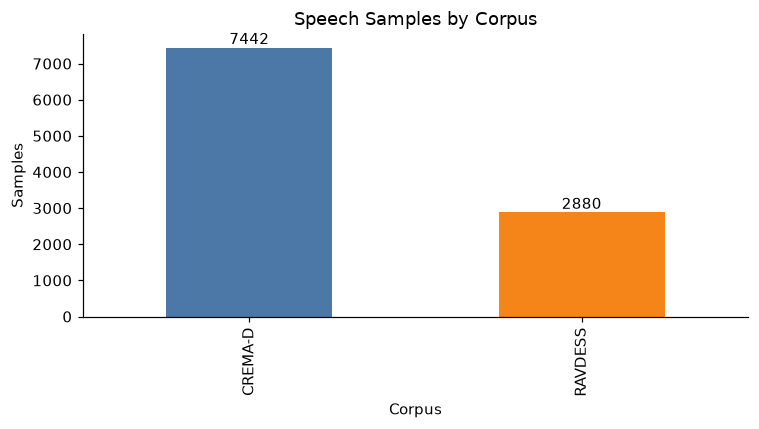

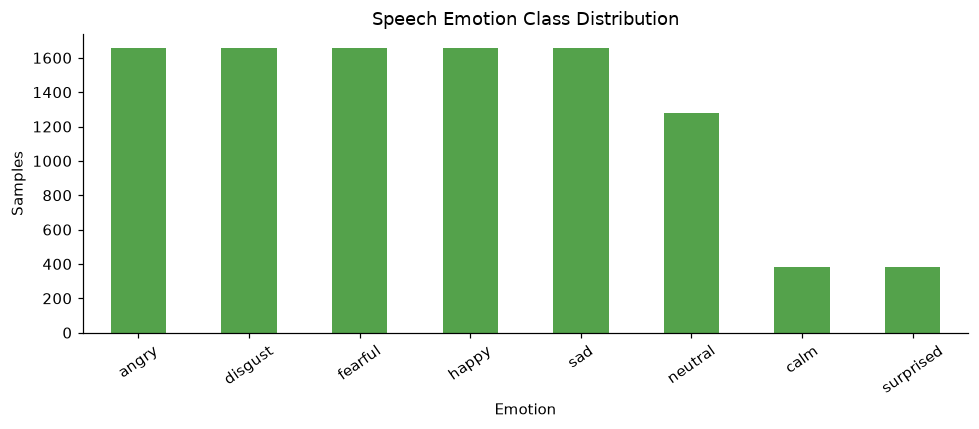

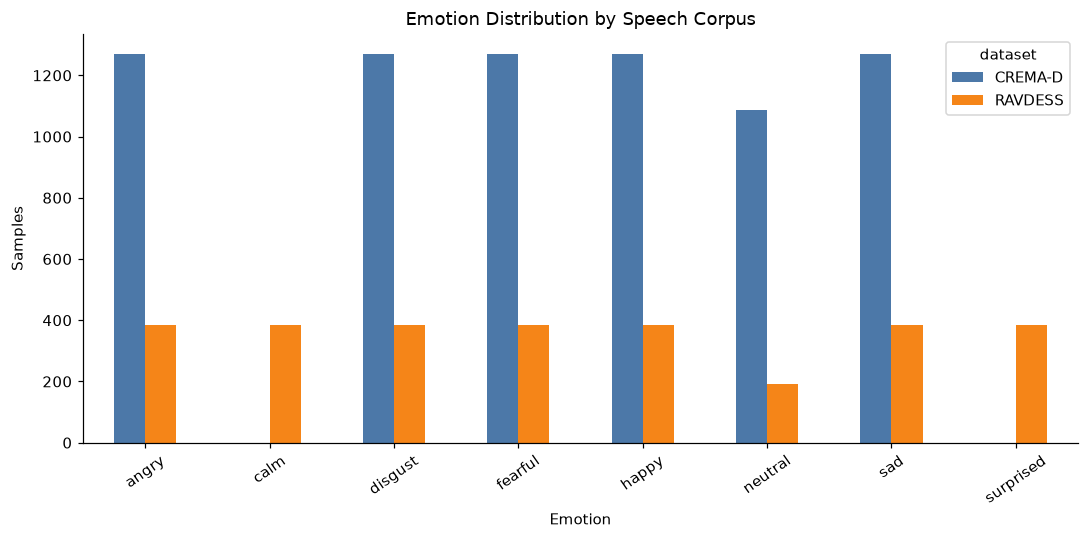

In [10]:
PLOT_STYLE = {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
plt.rcParams.update(PLOT_STYLE)

def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()


dataset_counts = speech["dataset"].value_counts().sort_index()
ax = dataset_counts.plot.bar(figsize=(7, 4), color=["#4C78A8", "#F58518"])
ax.set(title="Speech Samples by Corpus", xlabel="Corpus", ylabel="Samples")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
save_figure("speech_dataset_distribution.png")

emotion_counts = speech["emotion"].value_counts().sort_values(ascending=False)
ax = emotion_counts.plot.bar(figsize=(9, 4), color="#54A24B")
ax.set(title="Speech Emotion Class Distribution", xlabel="Emotion", ylabel="Samples")
ax.tick_params(axis="x", rotation=35)
save_figure("speech_emotion_distribution.png")

emotion_dataset = pd.crosstab(speech["emotion"], speech["dataset"]).sort_index()
ax = emotion_dataset.plot.bar(figsize=(10, 5), color=["#4C78A8", "#F58518"])
ax.set(title="Emotion Distribution by Speech Corpus", xlabel="Emotion", ylabel="Samples")
ax.tick_params(axis="x", rotation=35)
save_figure("speech_emotion_by_dataset.png")

## 8. DEAM Music Analysis

The V/A plane is the target space for the next project stage, when a defensible speech-emotion-to-V/A representation has been selected.

DEAM songs: 1,802
Music acoustic feature count: 182


,count,mean,std,min,25%,50%,75%,max
valence_mean,1802.0,0.097688,0.234633,-0.637343,-0.064162,0.109598,0.279371,0.63760
valence_std,1802.0,0.033603,0.025193,0.003982,0.017232,0.027068,0.041487,0.23632
valence_min,1802.0,0.033597,0.240152,-0.832000,-0.130791,0.041962,0.219750,0.56400
valence_max,1802.0,0.158987,0.227178,-0.569400,0.002162,0.173000,0.330456,0.71600
valence_range,1802.0,0.125389,0.086809,0.015652,0.071076,0.105398,0.153000,0.90400


,count,mean,std,min,25%,50%,75%,max
arousal_mean,1802.0,0.137346,0.279826,-0.673034,-0.068675,0.157133,0.369122,0.752033
arousal_std,1802.0,0.040464,0.036488,0.003730,0.018211,0.029986,0.049680,0.364664
arousal_min,1802.0,0.057858,0.285064,-0.772351,-0.161745,0.081000,0.291847,0.678000
arousal_max,1802.0,0.206280,0.280805,-0.654305,0.004811,0.225500,0.437000,0.898000
arousal_range,1802.0,0.148422,0.129918,0.016745,0.072330,0.114800,0.176952,1.354000


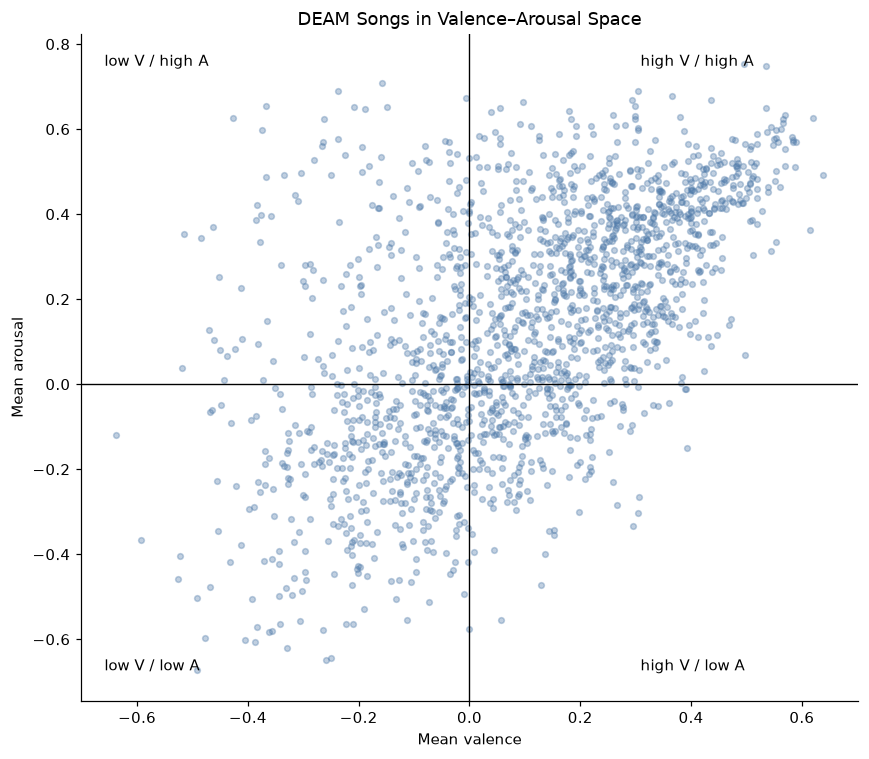

In [11]:
va_columns = ["valence_mean", "arousal_mean"]
if not set(va_columns).issubset(music.columns):
    raise KeyError(f"DEAM file must contain {va_columns}.")

music_acoustic_columns = [
    c for c in music.select_dtypes(include=np.number).columns
    if c not in {"song_id", "duration"} and not c.startswith(("valence_", "arousal_"))
]
print(f"DEAM songs: {len(music):,}")
print(f"Music acoustic feature count: {len(music_acoustic_columns)}")
display(music[[c for c in music.columns if c.startswith("valence_")]].describe().T)
display(music[[c for c in music.columns if c.startswith("arousal_")]].describe().T)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(music["valence_mean"], music["arousal_mean"], alpha=0.35, s=14, color="#4C78A8")
ax.axhline(0, color="black", linewidth=0.9)
ax.axvline(0, color="black", linewidth=0.9)
ax.text(0.03, 0.97, "low V / high A", transform=ax.transAxes, va="top")
ax.text(0.72, 0.97, "high V / high A", transform=ax.transAxes, va="top")
ax.text(0.03, 0.04, "low V / low A", transform=ax.transAxes, va="bottom")
ax.text(0.72, 0.04, "high V / low A", transform=ax.transAxes, va="bottom")
ax.set(title="DEAM Songs in Valence–Arousal Space", xlabel="Mean valence", ylabel="Mean arousal")
save_figure("deam_valence_arousal_space.png")

## 9. Music Acoustic PCA

Explained variance (PC1, PC2): [0.1981 0.1254]
Total explained variance: 0.3235


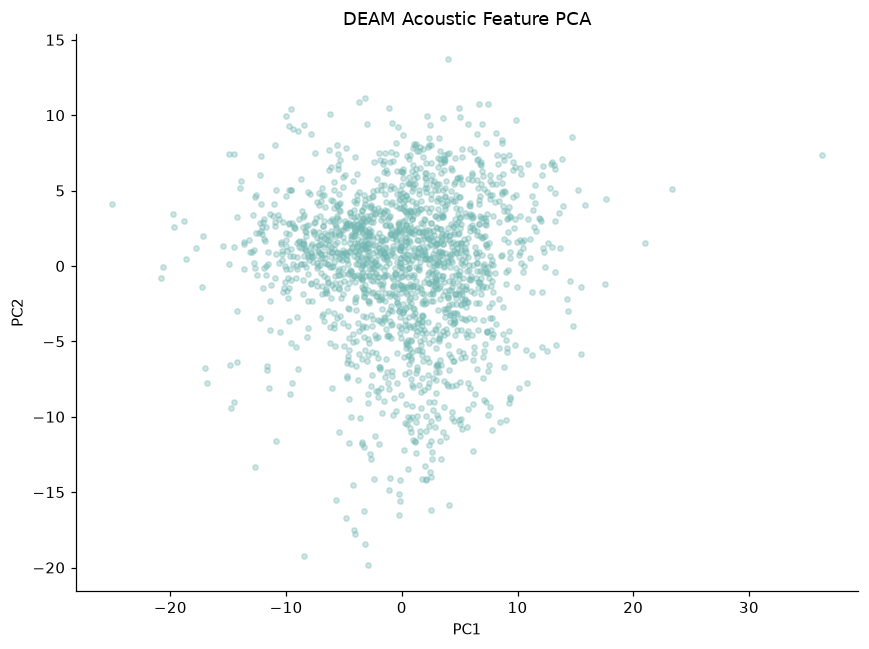

In [12]:
X_music = music[music_acoustic_columns].replace([np.inf, -np.inf], np.nan)
if X_music.isna().any().any():
    X_music = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_music), columns=X_music.columns)

music_pca = PCA(n_components=2, random_state=RANDOM_STATE)
music_pca_result = music_pca.fit_transform(StandardScaler().fit_transform(X_music))
print("Explained variance (PC1, PC2):", np.round(music_pca.explained_variance_ratio_, 4))
print("Total explained variance:", round(float(music_pca.explained_variance_ratio_.sum()), 4))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(music_pca_result[:, 0], music_pca_result[:, 1], alpha=0.35, s=12, color="#72B7B2")
ax.set(title="DEAM Acoustic Feature PCA", xlabel="PC1", ylabel="PC2")
save_figure("music_acoustic_pca.png")

## 10. Exploratory Speech PCA

This PCA standardizes the complete dataset **only for exploratory visualization**. It is not used for any train/test model evaluation, where preprocessing is fitted on the training partition only.

Explained variance (PC1, PC2): [0.3624 0.1543]
Total explained variance: 0.5167


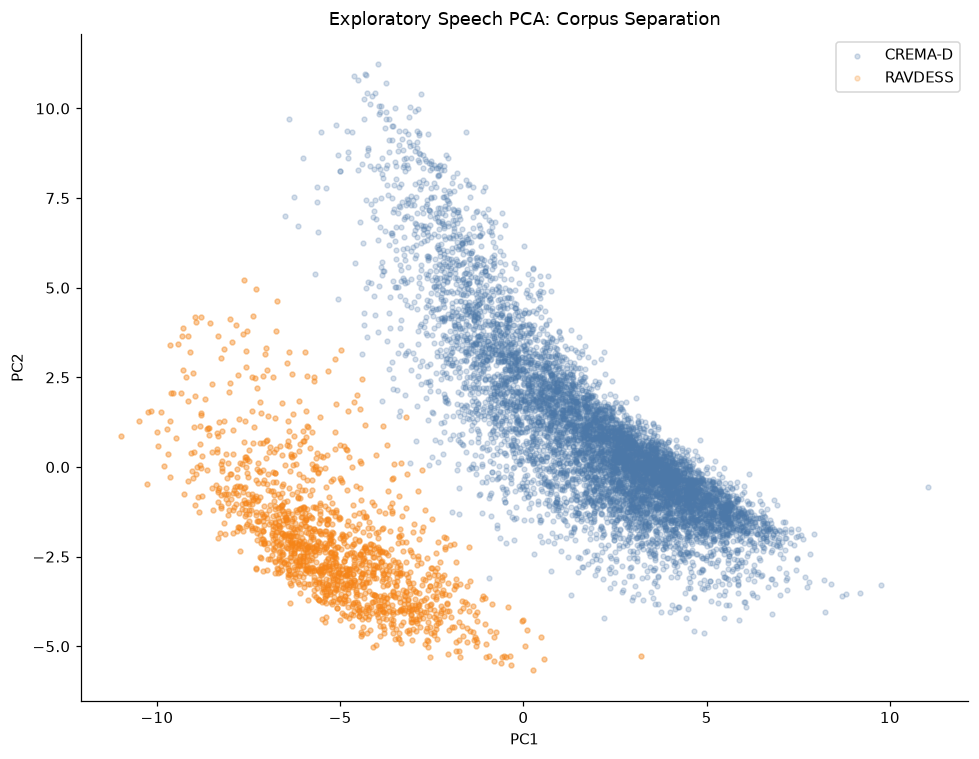

In [13]:
speech_pca = PCA(n_components=2, random_state=RANDOM_STATE)
speech_pca_result = speech_pca.fit_transform(StandardScaler().fit_transform(X_speech_clean))
print("Explained variance (PC1, PC2):", np.round(speech_pca.explained_variance_ratio_, 4))
print("Total explained variance:", round(float(speech_pca.explained_variance_ratio_.sum()), 4))

fig, ax = plt.subplots(figsize=(9, 7))
for domain, color in [("CREMA-D", "#4C78A8"), ("RAVDESS", "#F58518")]:
    mask = speech["dataset"].eq(domain)
    ax.scatter(speech_pca_result[mask, 0], speech_pca_result[mask, 1], alpha=0.23, s=10, label=domain, color=color)
ax.set(title="Exploratory Speech PCA: Corpus Separation", xlabel="PC1", ylabel="PC2")
ax.legend()
save_figure("speech_exploratory_pca_by_corpus.png")

**Interpretation.** Visible corpus separation indicates that dataset/domain information remains strongly encoded in the acoustic feature space.

## 11. Dataset-Shift Statistics

In [14]:
important_candidates = ["pitch_mean", "pitch_std", "energy_mean", "energy_std", "zcr_mean", "zcr_std", "jitter", "shimmer"]
available_shift_features = [c for c in important_candidates if c in X_speech_clean.columns]
if not available_shift_features:
    available_shift_features = NUMERIC_FEATURE_COLUMNS[:8]

crema_values = X_speech_clean.loc[speech["dataset"].eq("CREMA-D"), available_shift_features]
ravdess_values = X_speech_clean.loc[speech["dataset"].eq("RAVDESS"), available_shift_features]
pooled_sd = np.sqrt((crema_values.var(ddof=1) + ravdess_values.var(ddof=1)) / 2)
shift_statistics = pd.DataFrame({
    "CREMA-D_mean": crema_values.mean(),
    "RAVDESS_mean": ravdess_values.mean(),
    "mean_difference": crema_values.mean() - ravdess_values.mean(),
    "standardized_effect_difference": (crema_values.mean() - ravdess_values.mean()) / pooled_sd.replace(0, np.nan),
}).round(4)
display(shift_statistics)

,CREMA-D_mean,RAVDESS_mean,mean_difference,standardized_effect_difference
pitch_mean,143.6996,151.5636,-7.8641,-0.2665
pitch_std,61.8731,79.0349,-17.1618,-1.2277
energy_mean,0.0270,0.0101,0.0168,0.7880
energy_std,0.0279,0.0147,0.0132,0.4985
zcr_mean,0.0839,0.2626,-0.1787,-3.2081
zcr_std,0.0660,0.2106,-0.1446,-2.7269
jitter,0.0358,0.0252,0.0106,1.1011
shimmer,0.1966,0.1234,0.0731,2.6854


## 12. Domain Classification Baseline

A random forest predicts corpus membership from acoustic features. Both ordinary and balanced accuracy are reported because CREMA-D is the larger corpus.

,accuracy,balanced_accuracy
0,1.0,1.0


              precision    recall  f1-score   support

     CREMA-D     1.0000    1.0000    1.0000      1489
     RAVDESS     1.0000    1.0000    1.0000       576

    accuracy                         1.0000      2065
   macro avg     1.0000    1.0000    1.0000      2065
weighted avg     1.0000    1.0000    1.0000      2065



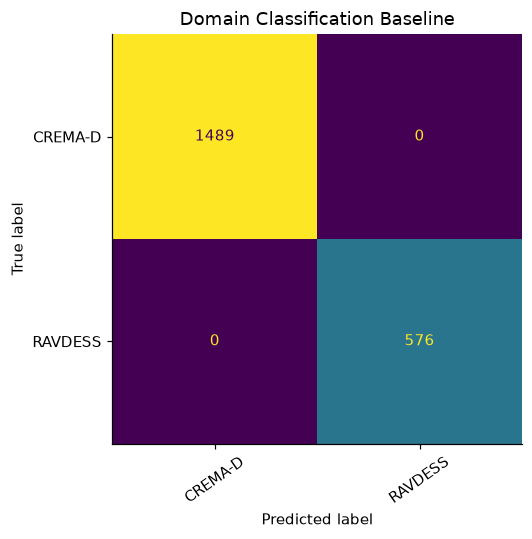

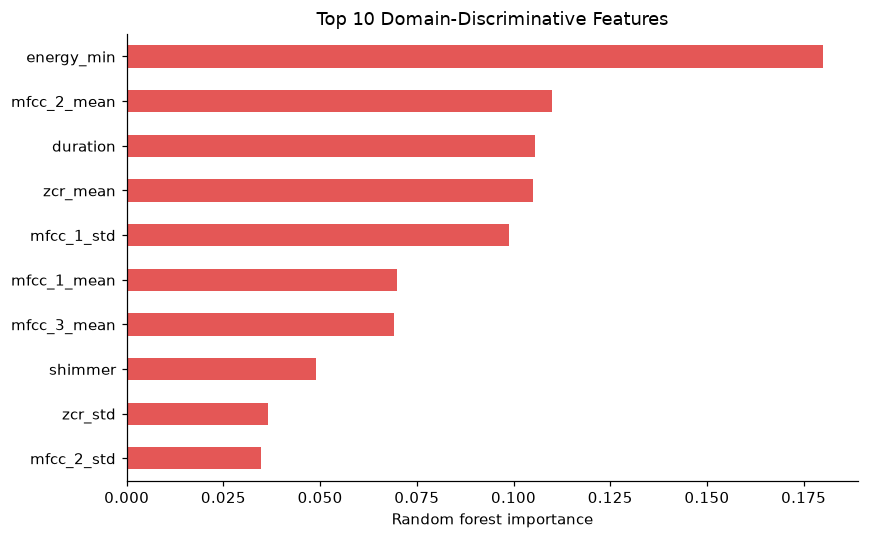

In [15]:
def fit_preprocessor(X_train, X_eval):
    """Fit median imputation and standardization on train only, then transform both sets."""
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train_ready = scaler.fit_transform(imputer.fit_transform(X_train))
    X_eval_ready = scaler.transform(imputer.transform(X_eval))
    return X_train_ready, X_eval_ready, imputer, scaler


def plot_confusion(y_true, y_pred, labels, title, filename, display_labels=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    if display_labels is None:
        display_labels = labels
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, labels=labels), display_labels=display_labels).plot(
        ax=ax, values_format="d", xticks_rotation=35, colorbar=False
    )
    ax.set_title(title)
    save_figure(filename)


domain_train_idx, domain_test_idx = train_test_split(
    np.arange(len(speech)), test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=speech["dataset"]
)
Xd_train, Xd_test, _, _ = fit_preprocessor(
    X_speech_raw.iloc[domain_train_idx], X_speech_raw.iloc[domain_test_idx]
)
yd_train = speech["dataset"].iloc[domain_train_idx]
yd_test = speech["dataset"].iloc[domain_test_idx]
domain_model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
domain_model.fit(Xd_train, yd_train)
domain_pred = domain_model.predict(Xd_test)
domain_accuracy = accuracy_score(yd_test, domain_pred)
domain_balanced_accuracy = balanced_accuracy_score(yd_test, domain_pred)
domain_baseline = pd.DataFrame([{"accuracy": domain_accuracy, "balanced_accuracy": domain_balanced_accuracy}])
domain_baseline.to_csv(REVIEW_DIR / "domain_baseline.csv", index=False)
display(domain_baseline.round(4))
print(classification_report(yd_test, domain_pred, digits=4))
plot_confusion(yd_test, domain_pred, ["CREMA-D", "RAVDESS"], "Domain Classification Baseline", "domain_baseline_confusion_matrix.png")

importance = pd.DataFrame({"feature": NUMERIC_FEATURE_COLUMNS, "importance": domain_model.feature_importances_}).sort_values("importance", ascending=False)
importance.head(10).to_csv(REVIEW_DIR / "domain_feature_importance.csv", index=False)
ax = importance.head(10).sort_values("importance").plot.barh(x="feature", y="importance", legend=False, figsize=(8, 5), color="#E45756")
ax.set(title="Top 10 Domain-Discriminative Features", xlabel="Random forest importance", ylabel="")
save_figure("domain_feature_importance.png")

## 13. Mixed-Dataset Emotion Baseline

This uses all eight emotions and a stratified random 80/20 split. It is an in-domain/mixed-corpus baseline, not evidence of cross-domain generalization.

,accuracy,macro_f1,weighted_f1
0,0.632,0.6832,0.6257


              precision    recall  f1-score   support

       angry     0.6943    0.8097    0.7476       331
        calm     0.8851    1.0000    0.9390        77
     disgust     0.6206    0.4743    0.5377       331
     fearful     0.7283    0.4048    0.5204       331
       happy     0.5677    0.5952    0.5811       331
     neutral     0.4560    0.6484    0.5355       256
         sad     0.6415    0.6918    0.6657       331
   surprised     0.8851    1.0000    0.9390        77

    accuracy                         0.6320      2065
   macro avg     0.6848    0.7030    0.6832      2065
weighted avg     0.6439    0.6320    0.6257      2065



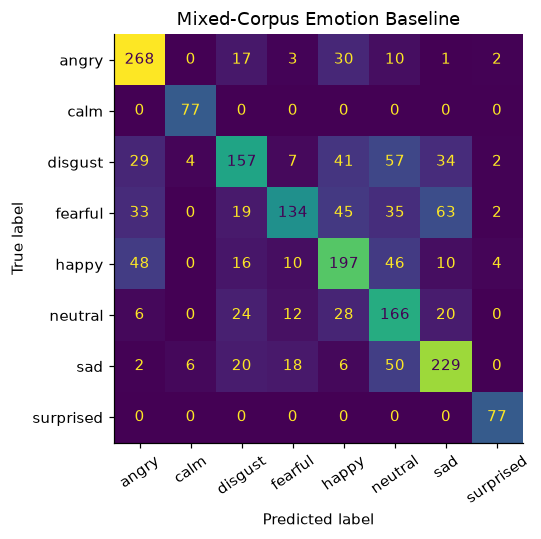

In [16]:
emotion_train_idx, emotion_test_idx = train_test_split(
    np.arange(len(speech)), test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=speech["emotion"]
)
Xe_train, Xe_test, _, _ = fit_preprocessor(
    X_speech_raw.iloc[emotion_train_idx], X_speech_raw.iloc[emotion_test_idx]
)
ye_train = speech["emotion"].iloc[emotion_train_idx]
ye_test = speech["emotion"].iloc[emotion_test_idx]
emotion_model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
emotion_model.fit(Xe_train, ye_train)
emotion_pred = emotion_model.predict(Xe_test)
emotion_baseline = pd.DataFrame([{
    "accuracy": accuracy_score(ye_test, emotion_pred),
    "macro_f1": f1_score(ye_test, emotion_pred, average="macro"),
    "weighted_f1": f1_score(ye_test, emotion_pred, average="weighted"),
}])
emotion_baseline.to_csv(REVIEW_DIR / "emotion_baseline.csv", index=False)
display(emotion_baseline.round(4))
print(classification_report(ye_test, emotion_pred, digits=4))
emotion_labels = sorted(speech["emotion"].unique())
plot_confusion(ye_test, emotion_pred, emotion_labels, "Mixed-Corpus Emotion Baseline", "emotion_baseline_confusion_matrix.png")

## 14. Cross-Corpus Baselines

Only the six emotions shared by CREMA-D and RAVDESS are used. Preprocessing is fitted on the source corpus only, then applied unchanged to the target corpus.

In [17]:
SHARED_EMOTIONS = ["angry", "disgust", "fearful", "happy", "neutral", "sad"]


def cross_corpus_random_forest(source_name, target_name, X_features=X_speech_raw, source_transform=None):
    mask = speech["emotion"].isin(SHARED_EMOTIONS)
    source_idx = speech.index[mask & speech["dataset"].eq(source_name)]
    target_idx = speech.index[mask & speech["dataset"].eq(target_name)]
    X_source = X_features.loc[source_idx]
    X_target = X_features.loc[target_idx]
    X_source_ready, X_target_ready, imputer, scaler = fit_preprocessor(X_source, X_target)
    if source_transform is not None:
        X_source_ready = source_transform(X_source_ready, X_target_ready)
    model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_source_ready, speech.loc[source_idx, "emotion"])
    pred = model.predict(X_target_ready)
    return {
        "direction": f"{source_name} → {target_name}",
        "accuracy": accuracy_score(speech.loc[target_idx, "emotion"], pred),
        "macro_f1": f1_score(speech.loc[target_idx, "emotion"], pred, average="macro"),
    }


cross_domain_results = pd.DataFrame([
    cross_corpus_random_forest("CREMA-D", "RAVDESS"),
    cross_corpus_random_forest("RAVDESS", "CREMA-D"),
])
cross_domain_results.to_csv(REVIEW_DIR / "cross_domain_results.csv", index=False)
display(cross_domain_results.round(4))

,direction,accuracy,macro_f1
0,CREMA-D → RAVDESS,0.3002,0.2172
1,RAVDESS → CREMA-D,0.2545,0.1649


## 15. CORAL

CORAL aligns source covariance to the unlabeled target covariance. This experiment measures both residual domain separability and actual cross-corpus emotion performance; alignment is not assumed to be effective.

In [18]:
def matrix_power_symmetric(matrix, power, epsilon=1e-6):
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = np.clip(eigenvalues, epsilon, None)
    return (eigenvectors * np.power(eigenvalues, power)) @ eigenvectors.T


class CORAL:
    def fit(self, X_source, X_target):
        self.source_mean_ = X_source.mean(axis=0, keepdims=True)
        self.target_mean_ = X_target.mean(axis=0, keepdims=True)
        n_features = X_source.shape[1]
        cs = np.cov(X_source - self.source_mean_, rowvar=False) + 1e-6 * np.eye(n_features)
        ct = np.cov(X_target - self.target_mean_, rowvar=False) + 1e-6 * np.eye(n_features)
        self.transform_ = matrix_power_symmetric(cs, -0.5) @ matrix_power_symmetric(ct, 0.5)
        return self

    def transform_source(self, X_source):
        return (X_source - self.source_mean_) @ self.transform_ + self.target_mean_


def coral_experiment(source_name, target_name):
    mask = speech["emotion"].isin(SHARED_EMOTIONS)
    source_idx = speech.index[mask & speech["dataset"].eq(source_name)]
    target_idx = speech.index[mask & speech["dataset"].eq(target_name)]
    src_train, src_test = train_test_split(source_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE,
                                           stratify=speech.loc[source_idx, "emotion"])
    tgt_train, tgt_test = train_test_split(target_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE,
                                           stratify=speech.loc[target_idx, "emotion"])
    X_src_train, X_src_test, imputer, scaler = fit_preprocessor(X_speech_raw.loc[src_train], X_speech_raw.loc[src_test])
    X_tgt_train = scaler.transform(imputer.transform(X_speech_raw.loc[tgt_train]))
    X_tgt_test = scaler.transform(imputer.transform(X_speech_raw.loc[tgt_test]))
    coral = CORAL().fit(X_src_train, X_tgt_train)
    X_src_train_aligned = coral.transform_source(X_src_train)
    X_src_test_aligned = coral.transform_source(X_src_test)

    before_model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    before_model.fit(X_src_train, speech.loc[src_train, "emotion"])
    after_model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    after_model.fit(X_src_train_aligned, speech.loc[src_train, "emotion"])
    y_target = speech.loc[tgt_test, "emotion"]
    before_pred = before_model.predict(X_tgt_test)
    after_pred = after_model.predict(X_tgt_test)

    def domain_score(source_train, source_test):
        train_x = np.vstack([source_train, X_tgt_train])
        test_x = np.vstack([source_test, X_tgt_test])
        train_y = np.array([source_name] * len(source_train) + [target_name] * len(X_tgt_train))
        test_y = np.array([source_name] * len(source_test) + [target_name] * len(X_tgt_test))
        clf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
        clf.fit(train_x, train_y)
        pred = clf.predict(test_x)
        return accuracy_score(test_y, pred), balanced_accuracy_score(test_y, pred)

    before_domain_acc, before_domain_bal = domain_score(X_src_train, X_src_test)
    after_domain_acc, after_domain_bal = domain_score(X_src_train_aligned, X_src_test_aligned)
    return [
        {"direction": f"{source_name} → {target_name}", "method": "Before CORAL", "emotion_accuracy": accuracy_score(y_target, before_pred), "emotion_macro_f1": f1_score(y_target, before_pred, average="macro"), "domain_accuracy": before_domain_acc, "domain_balanced_accuracy": before_domain_bal},
        {"direction": f"{source_name} → {target_name}", "method": "CORAL", "emotion_accuracy": accuracy_score(y_target, after_pred), "emotion_macro_f1": f1_score(y_target, after_pred, average="macro"), "domain_accuracy": after_domain_acc, "domain_balanced_accuracy": after_domain_bal},
    ]


coral_results = pd.DataFrame(coral_experiment("CREMA-D", "RAVDESS") + coral_experiment("RAVDESS", "CREMA-D"))
coral_results.to_csv(REVIEW_DIR / "coral_results.csv", index=False)
display(coral_results.round(4))

,direction,method,emotion_accuracy,emotion_macro_f1,domain_accuracy,domain_balanced_accuracy
0,CREMA-D → RAVDESS,Before CORAL,0.3097,0.2283,0.9995,0.9997
1,CREMA-D → RAVDESS,CORAL,0.4090,0.3946,1.0000,1.0000
2,RAVDESS → CREMA-D,Before CORAL,0.2693,0.1800,0.9995,0.9997
3,RAVDESS → CREMA-D,CORAL,0.3627,0.3439,0.9916,0.9912


## 16. DANN Architecture

```text
Input Features
     |
Feature Extractor
     |
+----+----------------+
|                     |
Emotion Head        GRL
|                     |
Emotion Loss       Domain Head
                      |
                  Domain Loss
```

The Gradient Reversal Layer (GRL) is identity during the forward pass and reverses/scales gradients received from the domain head during backpropagation. Here `lambda_grl` appears only in the GRL; total loss is `emotion_loss + domain_loss_weight * domain_loss`.

## 17. DANN Implementation

In [19]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, inputs, lambda_grl):
        ctx.lambda_grl = lambda_grl
        return inputs.view_as(inputs)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_grl * grad_output, None


def grad_reverse(inputs, lambda_grl):
    return GradientReversalFunction.apply(inputs, lambda_grl)


class DANN(nn.Module):
    def __init__(self, input_dim, n_emotions):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.20),
        )
        self.emotion_head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.20), nn.Linear(32, n_emotions))
        self.domain_head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.20), nn.Linear(32, 2))

    def forward(self, features, lambda_grl=0.0):
        embedding = self.feature_extractor(features)
        emotion_logits = self.emotion_head(embedding)
        domain_logits = self.domain_head(grad_reverse(embedding, lambda_grl))
        return emotion_logits, domain_logits, embedding

## 18. DANN Training

The mixed-corpus split is used only to evaluate this first adversarial representation experiment. Median imputation and scaling are fitted on its training partition only. A weighted sampler balances domains in DANN batches; emotion loss is class balanced.

In [20]:
DANN_CONFIG = {"epochs": 30, "batch_size": 128, "learning_rate": 1e-3, "lambda_max": 0.5, "domain_loss_weight": 1.0}


def make_dann_loaders(seed):
    train_idx, val_idx = train_test_split(np.arange(len(speech)), test_size=TEST_SIZE, random_state=seed, stratify=speech["emotion"])
    X_train, X_val, _, _ = fit_preprocessor(X_speech_raw.iloc[train_idx], X_speech_raw.iloc[val_idx])
    encoder = LabelEncoder().fit(speech["emotion"])
    y_train = encoder.transform(speech["emotion"].iloc[train_idx])
    y_val = encoder.transform(speech["emotion"].iloc[val_idx])
    d_train = speech["dataset"].iloc[train_idx].eq("RAVDESS").astype(int).to_numpy()
    d_val = speech["dataset"].iloc[val_idx].eq("RAVDESS").astype(int).to_numpy()
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train), torch.tensor(d_train))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val), torch.tensor(d_val))
    domain_counts = np.bincount(d_train, minlength=2)
    sample_weights = 1.0 / domain_counts[d_train]
    sampler = WeightedRandomSampler(torch.as_tensor(sample_weights, dtype=torch.double), len(sample_weights), replacement=True,
                                    generator=torch.Generator().manual_seed(seed))
    train_loader = DataLoader(train_ds, batch_size=DANN_CONFIG["batch_size"], sampler=sampler, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=0)
    class_weights = compute_class_weight("balanced", classes=np.arange(len(encoder.classes_)), y=y_train)
    domain_weights = len(d_train) / (2 * domain_counts)
    return train_loader, val_loader, X_train, X_val, y_train, y_val, d_train, d_val, encoder, class_weights, domain_weights


def evaluate_dann(model, loader):
    model.eval()
    emotion_true, emotion_pred, domain_true, domain_pred = [], [], [], []
    with torch.no_grad():
        for xb, yb, db in loader:
            e_logits, d_logits, _ = model(xb.to(DEVICE), lambda_grl=0.0)
            emotion_true.extend(yb.numpy())
            emotion_pred.extend(e_logits.argmax(dim=1).cpu().numpy())
            domain_true.extend(db.numpy())
            domain_pred.extend(d_logits.argmax(dim=1).cpu().numpy())
    return np.array(emotion_true), np.array(emotion_pred), np.array(domain_true), np.array(domain_pred)


def train_dann(seed, verbose=True):
    set_seed(seed)
    train_loader, val_loader, X_train, X_val, y_train, y_val, d_train, d_val, encoder, class_weights, domain_weights = make_dann_loaders(seed)
    model = DANN(X_train.shape[1], len(encoder.classes_)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=DANN_CONFIG["learning_rate"])
    emotion_criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
    domain_criterion = nn.CrossEntropyLoss(weight=torch.tensor(domain_weights, dtype=torch.float32, device=DEVICE))
    history = []
    total_steps = DANN_CONFIG["epochs"] * len(train_loader)
    current_step = 0
    for epoch in range(1, DANN_CONFIG["epochs"] + 1):
        model.train()
        total_losses, emotion_losses, domain_losses = [], [], []
        for xb, yb, db in train_loader:
            p = current_step / max(total_steps - 1, 1)
            lambda_grl = DANN_CONFIG["lambda_max"] * (2 / (1 + np.exp(-10 * p)) - 1)
            xb, yb, db = xb.to(DEVICE), yb.to(DEVICE), db.to(DEVICE)
            optimizer.zero_grad()
            e_logits, d_logits, _ = model(xb, lambda_grl=float(lambda_grl))
            emotion_loss = emotion_criterion(e_logits, yb)
            domain_loss = domain_criterion(d_logits, db)
            total_loss = emotion_loss + DANN_CONFIG["domain_loss_weight"] * domain_loss
            total_loss.backward()
            optimizer.step()
            total_losses.append(total_loss.item())
            emotion_losses.append(emotion_loss.item())
            domain_losses.append(domain_loss.item())
            current_step += 1
        e_true, e_pred, d_true, d_pred = evaluate_dann(model, val_loader)
        row = {"epoch": epoch, "total_loss": np.mean(total_losses), "emotion_loss": np.mean(emotion_losses), "domain_loss": np.mean(domain_losses),
               "validation_emotion_macro_f1": f1_score(e_true, e_pred, average="macro"), "validation_domain_balanced_accuracy": balanced_accuracy_score(d_true, d_pred)}
        history.append(row)
        if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == DANN_CONFIG["epochs"]):
            print(f"Epoch {epoch:02d}/{DANN_CONFIG['epochs']} | total={row['total_loss']:.4f} | emotion={row['emotion_loss']:.4f} | domain={row['domain_loss']:.4f} | val macro-F1={row['validation_emotion_macro_f1']:.4f} | val domain bal-acc={row['validation_domain_balanced_accuracy']:.4f}")
    return model, pd.DataFrame(history), (X_train, X_val, y_train, y_val, d_train, d_val, encoder), val_loader


start = time.time()
main_dann_model, main_dann_history, main_dann_data, main_dann_val_loader = train_dann(RANDOM_STATE)
print(f"Main DANN run completed in {(time.time() - start) / 60:.1f} minutes.")

Epoch 01/30 | total=2.1037 | emotion=1.7499 | domain=0.3538 | val macro-F1=0.3044 | val domain bal-acc=0.9723
Epoch 05/30 | total=1.6503 | emotion=1.1148 | domain=0.5355 | val macro-F1=0.4890 | val domain bal-acc=0.6409
Epoch 10/30 | total=1.4941 | emotion=0.9849 | domain=0.5092 | val macro-F1=0.5456 | val domain bal-acc=0.5479
Epoch 15/30 | total=1.4403 | emotion=0.9338 | domain=0.5065 | val macro-F1=0.5862 | val domain bal-acc=0.5343
Epoch 20/30 | total=1.3787 | emotion=0.8746 | domain=0.5042 | val macro-F1=0.6002 | val domain bal-acc=0.5629
Epoch 25/30 | total=1.3444 | emotion=0.8427 | domain=0.5017 | val macro-F1=0.6125 | val domain bal-acc=0.5652
Epoch 30/30 | total=1.2777 | emotion=0.7875 | domain=0.4902 | val macro-F1=0.6296 | val domain bal-acc=0.5915
Main DANN run completed in 0.3 minutes.


## 19. DANN Training Curves

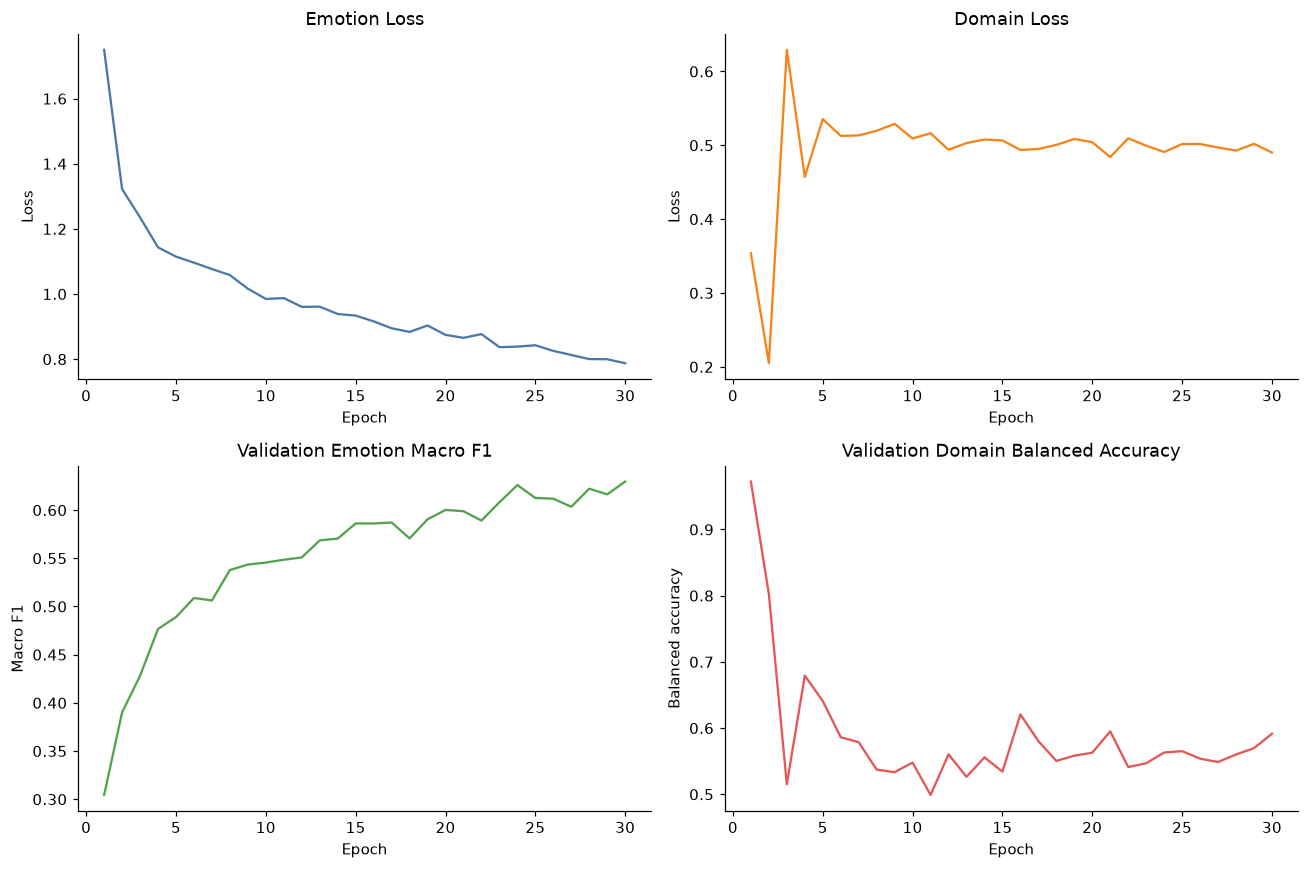

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(main_dann_history["epoch"], main_dann_history["emotion_loss"], color="#4C78A8"); axes[0, 0].set(title="Emotion Loss", xlabel="Epoch", ylabel="Loss")
axes[0, 1].plot(main_dann_history["epoch"], main_dann_history["domain_loss"], color="#F58518"); axes[0, 1].set(title="Domain Loss", xlabel="Epoch", ylabel="Loss")
axes[1, 0].plot(main_dann_history["epoch"], main_dann_history["validation_emotion_macro_f1"], color="#54A24B"); axes[1, 0].set(title="Validation Emotion Macro F1", xlabel="Epoch", ylabel="Macro F1")
axes[1, 1].plot(main_dann_history["epoch"], main_dann_history["validation_domain_balanced_accuracy"], color="#E45756"); axes[1, 1].set(title="Validation Domain Balanced Accuracy", xlabel="Epoch", ylabel="Balanced accuracy")
save_figure("dann_training_curves.png")

## 20. DANN Evaluation

,emotion_accuracy,emotion_macro_f1,domain_accuracy,domain_balanced_accuracy
0,0.5787,0.6296,0.432,0.5915


Emotion report:
               precision    recall  f1-score   support

       angry     0.7241    0.7613    0.7423       331
        calm     0.8202    0.9481    0.8795        77
     disgust     0.5567    0.4894    0.5209       331
     fearful     0.6321    0.4048    0.4936       331
       happy     0.5486    0.4773    0.5105       331
     neutral     0.3968    0.5781    0.4706       256
         sad     0.5245    0.5831    0.5522       331
   surprised     0.7812    0.9740    0.8671        77

    accuracy                         0.5787      2065
   macro avg     0.6230    0.6520    0.6296      2065
weighted avg     0.5875    0.5787    0.5754      2065



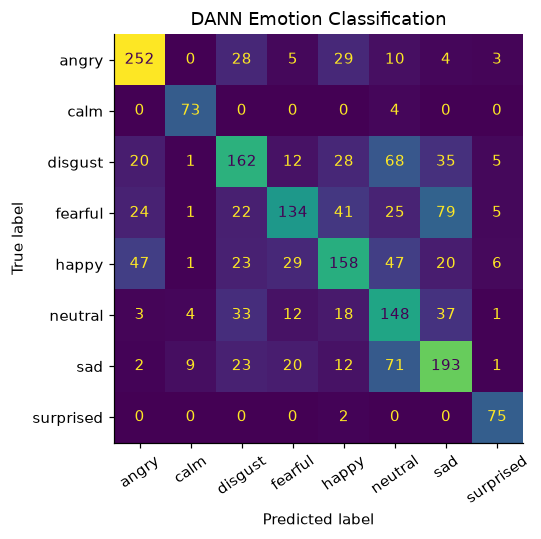

Domain report:
               precision    recall  f1-score   support

     CREMA-D     0.9410    0.2167    0.3523      1472
     RAVDESS     0.3320    0.9663    0.4942       593

    accuracy                         0.4320      2065
   macro avg     0.6365    0.5915    0.4232      2065
weighted avg     0.7661    0.4320    0.3930      2065



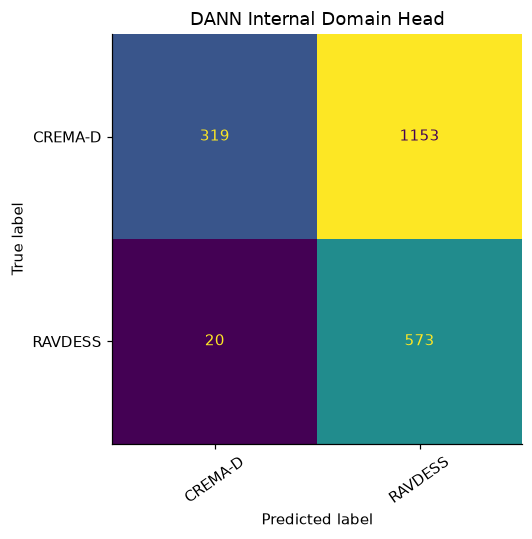

In [22]:
main_e_true, main_e_pred, main_d_true, main_d_pred = evaluate_dann(main_dann_model, main_dann_val_loader)
main_encoder = main_dann_data[-1]
main_dann_metrics = {
    "emotion_accuracy": accuracy_score(main_e_true, main_e_pred),
    "emotion_macro_f1": f1_score(main_e_true, main_e_pred, average="macro"),
    "domain_accuracy": accuracy_score(main_d_true, main_d_pred),
    "domain_balanced_accuracy": balanced_accuracy_score(main_d_true, main_d_pred),
}
display(pd.DataFrame([main_dann_metrics]).round(4))
print("Emotion report:\n", classification_report(main_e_true, main_e_pred, target_names=main_encoder.classes_, digits=4))
plot_confusion(main_e_true, main_e_pred, np.arange(len(main_encoder.classes_)), "DANN Emotion Classification", "dann_emotion_confusion_matrix.png", main_encoder.classes_)
print("Domain report:\n", classification_report(main_d_true, main_d_pred, target_names=["CREMA-D", "RAVDESS"], digits=4))
plot_confusion(main_d_true, main_d_pred, [0, 1], "DANN Internal Domain Head", "dann_domain_confusion_matrix.png", ["CREMA-D", "RAVDESS"])

## 21. Frozen-Embedding Domain Probe

A fresh balanced domain classifier is trained on frozen feature-extractor embeddings. This is a stronger check of remaining domain information than the adversarial domain head alone.

In [23]:
def extract_embeddings(model, features):
    model.eval()
    with torch.no_grad():
        tensor = torch.tensor(features, dtype=torch.float32, device=DEVICE)
        return model.feature_extractor(tensor).cpu().numpy()


X_train_main, X_val_main, _, _, d_train_main, d_val_main, _ = main_dann_data
train_embeddings = extract_embeddings(main_dann_model, X_train_main)
val_embeddings = extract_embeddings(main_dann_model, X_val_main)
domain_probe = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE))
domain_probe.fit(train_embeddings, d_train_main)
probe_pred = domain_probe.predict(val_embeddings)
main_dann_metrics["domain_probe_accuracy"] = accuracy_score(d_val_main, probe_pred)
main_dann_metrics["domain_probe_balanced_accuracy"] = balanced_accuracy_score(d_val_main, probe_pred)
display(pd.DataFrame([{"probe_accuracy": main_dann_metrics["domain_probe_accuracy"], "probe_balanced_accuracy": main_dann_metrics["domain_probe_balanced_accuracy"]}]).round(4))

,probe_accuracy,probe_balanced_accuracy
0,0.8731,0.8732


## 22. Five-Seed DANN Evaluation

The selected DANN configuration is evaluated over five seeds. The already-trained seed 42 model is reused, then the remaining four seeds are run.

In [24]:
def summarize_dann_run(seed, model, data, val_loader):
    X_train, X_val, _, _, d_train, d_val, _ = data
    e_true, e_pred, d_true, d_pred = evaluate_dann(model, val_loader)
    probe = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000, random_state=seed))
    probe.fit(extract_embeddings(model, X_train), d_train)
    domain_probe_pred = probe.predict(extract_embeddings(model, X_val))
    return {
        "seed": seed,
        "emotion_accuracy": accuracy_score(e_true, e_pred),
        "emotion_macro_f1": f1_score(e_true, e_pred, average="macro"),
        "domain_accuracy": accuracy_score(d_true, d_pred),
        "domain_balanced_accuracy": balanced_accuracy_score(d_true, d_pred),
        "domain_probe_balanced_accuracy": balanced_accuracy_score(d_val, domain_probe_pred),
    }


dann_seed_rows = [summarize_dann_run(RANDOM_STATE, main_dann_model, main_dann_data, main_dann_val_loader)]
for seed in SEEDS:
    if seed == RANDOM_STATE:
        continue
    start = time.time()
    model, _, data, val_loader = train_dann(seed, verbose=False)
    dann_seed_rows.append(summarize_dann_run(seed, model, data, val_loader))
    print(f"Seed {seed} completed in {(time.time() - start) / 60:.1f} minutes.")

dann_seed_results = pd.DataFrame(dann_seed_rows).sort_values("seed")
dann_seed_results.to_csv(REVIEW_DIR / "dann_seed_results.csv", index=False)
display(dann_seed_results.round(4))
display(pd.DataFrame([dann_seed_results.mean(numeric_only=True), dann_seed_results.std(numeric_only=True)], index=["mean", "std"]).round(4))

Seed 52 completed in 0.2 minutes.
Seed 62 completed in 0.2 minutes.
Seed 72 completed in 0.2 minutes.
Seed 82 completed in 0.4 minutes.


,seed,emotion_accuracy,emotion_macro_f1,domain_accuracy,domain_balanced_accuracy,domain_probe_balanced_accuracy
0,42,0.5787,0.6296,0.4320,0.5915,0.8732
1,52,0.5666,0.6065,0.3632,0.5504,0.8887
2,62,0.5593,0.5999,0.4199,0.5873,0.9362
3,72,0.5976,0.6251,0.3792,0.5555,0.9383
4,82,0.5734,0.6174,0.3637,0.5427,0.9345


,seed,emotion_accuracy,emotion_macro_f1,domain_accuracy,domain_balanced_accuracy,domain_probe_balanced_accuracy
mean,62.0000,0.5751,0.6157,0.3916,0.5655,0.9142
std,15.8114,0.0145,0.0124,0.0323,0.0223,0.0308


## 23. Final Results Table

Metrics are only shown where the comparison is conceptually applicable. DANN’s mixed-corpus result and the cross-corpus results answer different questions and should not be treated as interchangeable.

In [25]:
coral_summary = coral_results[coral_results["method"].eq("CORAL")].groupby("method").mean(numeric_only=True).iloc[0]
final_results = pd.DataFrame([
    {"Method": "Supervised mixed baseline", "Emotion Accuracy": emotion_baseline.loc[0, "accuracy"], "Emotion Macro F1": emotion_baseline.loc[0, "macro_f1"], "Cross-Domain Macro F1": np.nan, "Domain Accuracy": domain_accuracy, "Domain Balanced Accuracy": domain_balanced_accuracy},
    {"Method": "Cross-corpus baseline (mean)", "Emotion Accuracy": cross_domain_results["accuracy"].mean(), "Emotion Macro F1": cross_domain_results["macro_f1"].mean(), "Cross-Domain Macro F1": cross_domain_results["macro_f1"].mean(), "Domain Accuracy": np.nan, "Domain Balanced Accuracy": np.nan},
    {"Method": "CORAL (mean)", "Emotion Accuracy": coral_summary["emotion_accuracy"], "Emotion Macro F1": coral_summary["emotion_macro_f1"], "Cross-Domain Macro F1": coral_summary["emotion_macro_f1"], "Domain Accuracy": coral_summary["domain_accuracy"], "Domain Balanced Accuracy": coral_summary["domain_balanced_accuracy"]},
    {"Method": "DANN (five-seed mean)", "Emotion Accuracy": dann_seed_results["emotion_accuracy"].mean(), "Emotion Macro F1": dann_seed_results["emotion_macro_f1"].mean(), "Cross-Domain Macro F1": np.nan, "Domain Accuracy": dann_seed_results["domain_accuracy"].mean(), "Domain Balanced Accuracy": dann_seed_results["domain_balanced_accuracy"].mean()},
])
final_results.to_csv(REVIEW_DIR / "final_results.csv", index=False)
display(final_results.round(4))

,Method,Emotion Accuracy,Emotion Macro F1,Cross-Domain Macro F1,Domain Accuracy,Domain Balanced Accuracy
0,Supervised mixed baseline,0.6320,0.6832,NaN,1.0000,1.0000
1,Cross-corpus baseline (mean),0.2773,0.1911,0.1911,NaN,NaN
2,CORAL (mean),0.3858,0.3693,0.3693,0.9958,0.9956
3,DANN (five-seed mean),0.5751,0.6157,NaN,0.3916,0.5655


## 24. Review 1 Key Findings

- CREMA-D and RAVDESS exhibit strong acoustic domain shift.
- Mixed-corpus emotion classification is substantially easier than cross-corpus emotion generalization.
- CORAL may not sufficiently eliminate nonlinear corpus differences.
- DANN can reduce some directly accessible domain information, but domain confusion alone does not guarantee improved emotion recognition.
- Current work establishes the foundation for a robust speech-to-music emotion pipeline.

The values above determine the strength of each statement; no method is claimed to improve emotion recognition unless its measured result shows it.

## 25. Review 1 Completion Status

In [26]:
completion_status = pd.DataFrame([
    ("Speech dataset preparation", "DONE"), ("Music dataset preparation", "DONE"),
    ("Speech feature extraction", "DONE"), ("Music feature extraction", "DONE"),
    ("Data validation", "DONE"), ("Speech EDA", "DONE"), ("Music V/A analysis", "DONE"),
    ("Domain-shift analysis", "DONE"), ("Baseline emotion classifier", "DONE"),
    ("Cross-corpus evaluation", "DONE"), ("CORAL experiment", "DONE"),
    ("DANN experiment", "DONE"), ("Multi-seed evaluation", "DONE"),
    ("Speech-to-V/A mapping", "NEXT"), ("Music ranking/recommendation", "NEXT"), ("Personalization", "FUTURE"),
], columns=["Component", "Status"])
display(completion_status)

,Component,Status
0,Speech dataset preparation,DONE
1,Music dataset preparation,DONE
2,Speech feature extraction,DONE
3,Music feature extraction,DONE
4,Data validation,DONE
5,Speech EDA,DONE
6,Music V/A analysis,DONE
7,Domain-shift analysis,DONE
8,Baseline emotion classifier,DONE
9,Cross-corpus evaluation,DONE


## 26. Next Stage

```text
Speech
  |
  v
Emotion probabilities
  |
  v
Probability-weighted Valence/Arousal estimate
  |
  v
Match against DEAM V/A coordinates
  |
  v
Top-K song ranking
  |
  v
Acoustic diversity / personalization
```

Categorical emotion must be mapped to V/A using either (a) a documented literature-based mapping, or (b) a dataset/model with continuous V/A supervision. An arbitrary mapping must not be presented as ground truth.

## 27. Save Review Outputs

The tables and plots were written throughout the notebook to `data/processed/review_1/` and `data/processed/review_1/figures/`.

In [27]:
expected_outputs = [
    "dataset_summary.csv", "domain_baseline.csv", "emotion_baseline.csv",
    "cross_domain_results.csv", "coral_results.csv", "dann_seed_results.csv",
    "final_results.csv", "domain_feature_importance.csv",
]
missing_outputs = [name for name in expected_outputs if not (REVIEW_DIR / name).is_file()]
if missing_outputs:
    raise RuntimeError(f"Expected Review 1 outputs were not created: {missing_outputs}")
print("Saved review tables:")
for output in expected_outputs:
    print(" -", REVIEW_DIR / output)
print(f"Saved figures: {len(list(FIGURE_DIR.glob('*.png')))}")

Saved review tables:
 - C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1\dataset_summary.csv
 - C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1\domain_baseline.csv
 - C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1\emotion_baseline.csv
 - C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1\cross_domain_results.csv
 - C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1\coral_results.csv
 - C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1\dann_seed_results.csv
 - C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1\final_results.csv
 - C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\processed\review_1\domain_feature_importance.csv
Saved figures: 12
